<a href="https://colab.research.google.com/github/marantmir/pos_graduacao_ia_aplicada_sesi_senai_sc/blob/main/aprendizado_profundo/Aula_01_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# PERCEPTRON SIMPLES EM MAKE_MOONS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Gerar dataset não linear (duas luas)
# ------------------------------------------------------------
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

# Normalizar para facilitar o treinamento
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Dividir entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### **Explicação do código anterior**


**`X, y = make_moons(n_samples=400, noise=0.25, random_state=42)`**<br><br>
Imagine que você quer ensinar um computador a diferenciar entre dois tipos de coisas, por exemplo, maçãs e laranjas. Para fazer isso, você precisa de exemplos. A linha de código `make_moons` é como um gerador de exemplos artificial para um problema específico.

**`make_moons`:** Essa função cria um conjunto de dados que se parece com duas "luas" entrelaçadas ou dois arcos. É um problema clássico em aprendizado de máquina porque não é possível traçar uma linha reta para separar as duas "luas". Isso ajuda a testar algoritmos mais complexos.

**`n_samples=400`:** Isso significa que estamos pedindo para o gerador criar um total de 400 pontos de dados, ou seja, 400 "exemplos" (maçãs e laranjas, na nossa analogia).

**`noise=0.25`:** Imagine que nossos pontos de dados não são perfeitamente arrumados; eles têm um pouco de "bagunça" ou variações. O `noise` controla o quanto dessa bagunça é adicionada. Um valor de 0.25 significa que os pontos não estarão exatamente na forma das luas, mas um pouco espalhados, tornando o problema mais realista e desafiador.

**`random_state=42`:** Isso é como uma "semente" para o gerador de números aleatórios. Se você usar o mesmo `random_state` (aqui, 42), toda vez que rodar o código, você obterá exatamente o mesmo conjunto de 400 pontos com a mesma "bagunça". Isso é útil para que as pessoas possam reproduzir seus resultados e comparar experimentos.

**O que `X `e y significam?**

- **`X`:** Contém as "características" de cada ponto. No nosso caso, como é um problema 2D, `X` terá duas colunas para cada ponto (por exemplo, a posição horizontal e vertical do ponto no gráfico).

- **y:** Contém os "rótulos" ou "classes" de cada ponto. Para o problema das luas, `y` dirá se um ponto pertence à "lua de cima" (digamos, representado por 0) ou à "lua de baixo" (representado por 1).

**`scaler = StandardScaler()`**

**`X = scaler.fit_transform(X)`**

Agora que temos nossos 400 pontos, é uma boa prática "normalizá-los". Pense nisso como colocar todos os seus dados na mesma escala ou unidade de medida.

StandardScaler(): É uma ferramenta que padroniza os dados. Ela transforma cada característica (cada coluna de X) de forma que sua média seja 0 e seu desvio padrão (uma medida de dispersão) seja 1.
Por que isso é importante?

Imagine que uma das características do seu dado vai de 0 a 1000, e a outra vai de 0 a 1. Se você não normalizar, a característica que varia de 0 a 1000 vai "dominar" o processo de aprendizado, e a de 0 a 1 quase não terá impacto. A normalização garante que todas as características tenham a mesma importância no cálculo do modelo, o que ajuda muitos algoritmos a aprenderem de forma mais eficaz e rápida. É como se você tivesse que comparar a altura de pessoas (metros) e o peso (quilogramas); para uma análise justa, talvez você queira ver ambos em uma escala comparável.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
Por fim, depois de gerar e arrumar os dados, precisamos dividi-los em duas partes: uma para ensinar o computador e outra para testar o que ele aprendeu.

train_test_split(): Essa função faz exatamente isso: divide seus dados de entrada (X) e seus rótulos (y) em conjuntos de treino e teste.
test_size=0.3: Isso significa que 30% dos seus 400 pontos serão usados para teste, e os outros 70% (1 - 0.3 = 0.7) serão usados para treino. É crucial separar os dados assim para que o computador seja avaliado em exemplos que nunca viu durante o aprendizado, dando uma medida mais honesta de quão bem ele generaliza para novos dados.
random_state=42: Assim como antes, isso garante que a divisão seja sempre a mesma se você rodar o código novamente, mantendo a consistência dos seus experimentos.
O que cada variável representa agora?

X_train: As características dos pontos que serão usados para treinar o modelo.
X_test: As características dos pontos que serão usados para testar o modelo depois do treino.
y_train: Os rótulos (as "respostas corretas") correspondentes aos X_train.
y_test: Os rótulos (as "respostas corretas") correspondentes aos X_test.
Em resumo, este bloco de código está criando um problema de classificação de dados não linear, preparando esses dados para o aprendizado de máquina e, em seguida, organizando-os em conjuntos de treino e teste para que um modelo possa ser ensinado e avaliado de forma justa.

In [ ]:
# ------------------------------------------------------------
# 2. Inicialização de parâmetros
# ------------------------------------------------------------
np.random.seed(0)
weights = np.random.randn(2) * 0.5  # pesos iniciais
bias = np.random.randn() * 0.5      # bias inicial
learning_rate = 0.01
epochs = 50

In [ ]:
# ------------------------------------------------------------
# 3. Funções auxiliares
# ------------------------------------------------------------
def step_function(x):
    """Função de ativação degrau."""
    return np.where(x >= 0, 1, 0)

def predict(inputs):
    """Calcula a saída do perceptron."""
    return step_function(np.dot(inputs, weights) + bias)


In [ ]:
# ------------------------------------------------------------
# 4. Treinamento do Perceptron
# ------------------------------------------------------------
errors = []

for epoch in range(epochs):
    total_error = 0
    for xi, target in zip(X_train, y_train):
        output = predict(xi)
        error = target - output
        weights += learning_rate * error * xi
        bias += learning_rate * error
        total_error += abs(error)

    errors.append(total_error)
    print(f"Época {epoch+1}/{epochs} | Erros: {total_error}")

Época 1/50 | Erros: 82
Época 2/50 | Erros: 58
Época 3/50 | Erros: 45
Época 4/50 | Erros: 44
Época 5/50 | Erros: 53
Época 6/50 | Erros: 54
Época 7/50 | Erros: 54
Época 8/50 | Erros: 58
Época 9/50 | Erros: 58
Época 10/50 | Erros: 54
Época 11/50 | Erros: 56
Época 12/50 | Erros: 56
Época 13/50 | Erros: 50
Época 14/50 | Erros: 56
Época 15/50 | Erros: 54
Época 16/50 | Erros: 56
Época 17/50 | Erros: 56
Época 18/50 | Erros: 60
Época 19/50 | Erros: 60
Época 20/50 | Erros: 54
Época 21/50 | Erros: 60
Época 22/50 | Erros: 53
Época 23/50 | Erros: 58
Época 24/50 | Erros: 61
Época 25/50 | Erros: 60
Época 26/50 | Erros: 56
Época 27/50 | Erros: 52
Época 28/50 | Erros: 56
Época 29/50 | Erros: 59
Época 30/50 | Erros: 61
Época 31/50 | Erros: 58
Época 32/50 | Erros: 54
Época 33/50 | Erros: 58
Época 34/50 | Erros: 54
Época 35/50 | Erros: 54
Época 36/50 | Erros: 58
Época 37/50 | Erros: 53
Época 38/50 | Erros: 53
Época 39/50 | Erros: 56
Época 40/50 | Erros: 56
Época 41/50 | Erros: 54
Época 42/50 | Erros: 56
É

In [ ]:
# ------------------------------------------------------------
# 5. Avaliação de desempenho
# ------------------------------------------------------------
y_pred = predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"\nAcurácia no conjunto de teste: {accuracy*100:.2f}%")


Acurácia no conjunto de teste: 76.67%


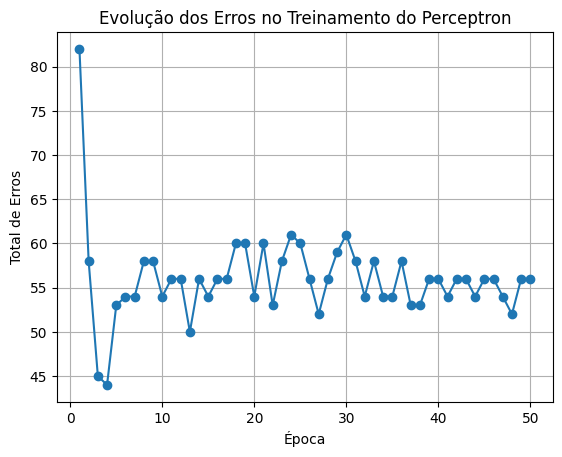

In [ ]:
# ------------------------------------------------------------
# 6. Visualização da evolução do erro
# ------------------------------------------------------------
plt.plot(range(1, epochs+1), errors, marker='o')
plt.title("Evolução dos Erros no Treinamento do Perceptron")
plt.xlabel("Época")
plt.ylabel("Total de Erros")
plt.grid(True)
plt.show()

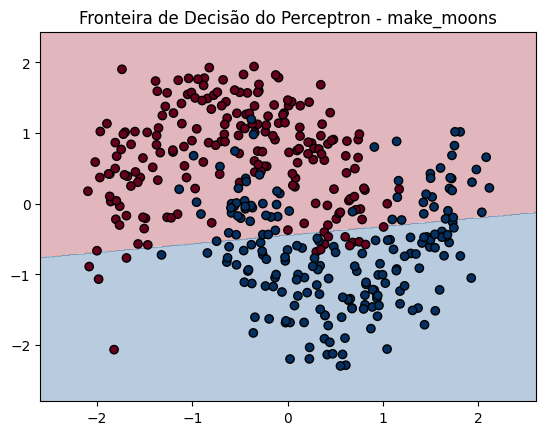

In [ ]:
# ------------------------------------------------------------
# 7. Visualização da fronteira de decisão
# ------------------------------------------------------------
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=plt.cm.RdBu)
plt.title("Fronteira de Decisão do Perceptron - make_moons")
plt.show()

In [ ]:
# ============================================================
# PERCEPTRON SIMPLES EM MAKE_MOONS (PyTorch)
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# ------------------------------------------------------------
# 1. Gerar dataset não linear (duas luas)
# ------------------------------------------------------------
X, y = make_moons(n_samples=400, noise=0.25, random_state=42)

# Normalizar para facilitar o treinamento
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Dividir entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Converter para tensores PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [ ]:
# ------------------------------------------------------------
# 2. Definir Perceptron usando PyTorch
# ------------------------------------------------------------
class Perceptron(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Linear layer cria pesos e bias automaticamente
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        # Função de ativação degrau
        z = self.linear(x)
        return (z >= 0).float()  # step function

# Instanciar o modelo
model = Perceptron(input_dim=2)

In [ ]:
# ------------------------------------------------------------
# 3. Definir otimização e critério
# ------------------------------------------------------------
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()  # Treinamento com gradiente, mesmo que seja step function


In [ ]:
# ------------------------------------------------------------
# 4. Treinamento do Perceptron (atualização direta)
# ------------------------------------------------------------
epochs = 50
learning_rate = 0.01
errors = []

for epoch in range(epochs):
    total_error = 0

    # Percorrer cada amostra
    for xi, target in zip(X_train_t, y_train_t):
        # Forward pass com step function
        output = (model.linear(xi) >= 0).float()

        # Calcular erro
        error = target - output

        # Atualização manual de pesos e bias
        with torch.no_grad():  # não acumula gradientes
            model.linear.weight += learning_rate * error * xi
            model.linear.bias += learning_rate * error

        total_error += abs(error.item())

    errors.append(total_error)
    print(f"Época {epoch+1}/{epochs} | Total de erros: {total_error}")


Época 1/50 | Total de erros: 66.0
Época 2/50 | Total de erros: 45.0
Época 3/50 | Total de erros: 49.0
Época 4/50 | Total de erros: 58.0
Época 5/50 | Total de erros: 58.0
Época 6/50 | Total de erros: 54.0
Época 7/50 | Total de erros: 50.0
Época 8/50 | Total de erros: 62.0
Época 9/50 | Total de erros: 55.0
Época 10/50 | Total de erros: 53.0
Época 11/50 | Total de erros: 58.0
Época 12/50 | Total de erros: 56.0
Época 13/50 | Total de erros: 56.0
Época 14/50 | Total de erros: 56.0
Época 15/50 | Total de erros: 58.0
Época 16/50 | Total de erros: 56.0
Época 17/50 | Total de erros: 48.0
Época 18/50 | Total de erros: 55.0
Época 19/50 | Total de erros: 53.0
Época 20/50 | Total de erros: 58.0
Época 21/50 | Total de erros: 56.0
Época 22/50 | Total de erros: 58.0
Época 23/50 | Total de erros: 56.0
Época 24/50 | Total de erros: 56.0
Época 25/50 | Total de erros: 56.0
Época 26/50 | Total de erros: 58.0
Época 27/50 | Total de erros: 52.0
Época 28/50 | Total de erros: 57.0
Época 29/50 | Total de erros:

In [ ]:
# ------------------------------------------------------------
# 5. Avaliação no conjunto de teste
# ------------------------------------------------------------
with torch.no_grad():
    y_pred_test = (model.linear(X_test_t) >= 0).float()
    accuracy = (y_pred_test == y_test_t).float().mean().item()
print(f"\nAcurácia no conjunto de teste: {accuracy*100:.2f}%")


Acurácia no conjunto de teste: 80.00%


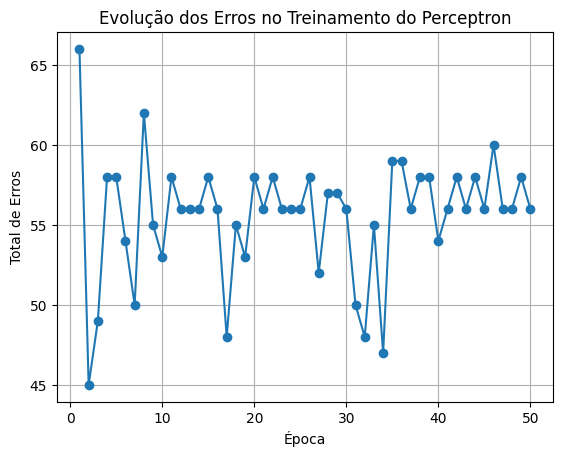

In [ ]:
# ------------------------------------------------------------
# 6. Visualização da evolução do erro
# ------------------------------------------------------------
plt.plot(range(1, epochs+1), errors, marker='o')
plt.title("Evolução dos Erros no Treinamento do Perceptron")
plt.xlabel("Época")
plt.ylabel("Total de Erros")
plt.grid(True)
plt.show()

In [ ]:
# ------------------------------------------------------------
# 7. Visualização da fronteira de decisão
# ------------------------------------------------------------
x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_t = torch.tensor(grid, dtype=torch.float32)

with torch.no_grad():
    Z = (model.linear(grid_t) >= 0).float().numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.RdBu)
plt.title("Fronteira de Decisão do Perceptron - PyTorch")
plt.show()


In [ ]:
# ============================================================
# PERCEPTRON SIMPLES (ATUALIZAÇÃO DIRETA) - BREAST CANCER
# ============================================================

import torch
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Carregar e preparar o dataset
# ------------------------------------------------------------
data = load_breast_cancer()
X, y = data.data, data.target

# Normalizar os dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Converter para tensores PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# ------------------------------------------------------------
# 2. Definir Perceptron
# ------------------------------------------------------------
class Perceptron(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Linear layer cria pesos e bias automaticamente
        self.linear = torch.nn.Linear(input_dim, 1)

    def forward(self, x):
        # Step function (0 ou 1)
        return (self.linear(x) >= 0).float()

input_dim = X_train.shape[1]
model = Perceptron(input_dim)

# ------------------------------------------------------------
# 3. Treinamento (atualização direta)
# ------------------------------------------------------------
epochs = 50       # <<< experimente alterar
learning_rate = 0.01  # <<< experimente alterar
errors = []

for epoch in range(epochs):
    total_error = 0

    for xi, target in zip(X_train_t, y_train_t):
        # Forward pass
        output = (model.linear(xi) >= 0).float()

        # Erro
        error = target - output

        # Atualização manual de pesos e bias
        with torch.no_grad():
            model.linear.weight += learning_rate * error * xi
            model.linear.bias += learning_rate * error

        total_error += abs(error.item())

    errors.append(total_error)
    print(f"Época {epoch+1}/{epochs} | Total de erros: {total_error}")

# ------------------------------------------------------------
# 4. Avaliação no conjunto de teste
# ------------------------------------------------------------
with torch.no_grad():
    y_pred = (model.linear(X_test_t) >= 0).float()
    accuracy = (y_pred == y_test_t).float().mean().item()
print(f"\nAcurácia no conjunto de teste: {accuracy*100:.2f}%")

# ------------------------------------------------------------
# 5. Visualização da evolução do erro
# ------------------------------------------------------------
plt.plot(range(1, epochs+1), errors, marker='o')
plt.xlabel('Época')
plt.ylabel('Total de Erros')
plt.title('Evolução dos Erros - Perceptron Breast Cancer')
plt.grid(True)
plt.show()